In [2]:
import tensorflow as tf

In [3]:
from tensorflow import keras
from keras import layers
import matplotlib.pyplot as plt

In [4]:
cifar=keras.datasets.cifar10
(x_train,y_train),(x_test,y_test) = cifar.load_data()
x_train,x_test = x_train/255.0,x_test/255.0

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [5]:
from keras import datasets,models

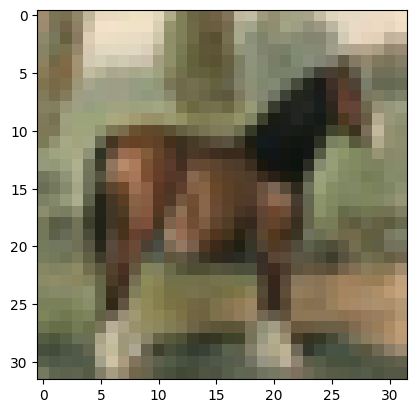

In [6]:
plt.imshow(x_train[994])

In [7]:
model = keras.Sequential()
model.add(layers.Conv2D(32 , (3,3) ,activation = 'relu' , input_shape=(32,32,3)))
model.add(layers.MaxPooling2D((2,2)))
model.add(layers.Conv2D(64 , (3,3) ,activation = 'relu'))
model.add(layers.MaxPooling2D((2,2)))
model.add(layers.Conv2D(64 , (3,3) ,activation = 'relu'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
model.add(layers.Flatten())
model.add(layers.Dense(128, activation='relu'))
model.add(layers.Dense(10 , activation = 'softmax'))

In [9]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [10]:
x_train.shape

(50000, 32, 32, 3)

In [11]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 188,810 (737.54 KB)

 Trainable params: 188,810 (737.54 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
history=model.fit(x_train, y_train,validation_split=0.1, epochs=5)

Epoch 1/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 71s 49ms/step - accuracy: 0.4442 - loss: 1.5298 - val_accuracy: 0.5296 - val_loss: 1.2904
Epoch 2/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 66s 47ms/step - accuracy: 0.5814 - loss: 1.1845 - val_accuracy: 0.5918 - val_loss: 1.1680
Epoch 3/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 83s 47ms/step - accuracy: 0.6360 - loss: 1.0302 - val_accuracy: 0.6592 - val_loss: 0.9654
Epoch 4/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 66s 47ms/step - accuracy: 0.6741 - loss: 0.9255 - val_accuracy: 0.6734 - val_loss: 0.9484
Epoch 5/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 81s 46ms/step - accuracy: 0.7057 - loss: 0.8438 - val_accuracy: 0.6954 - val_loss: 0.8669


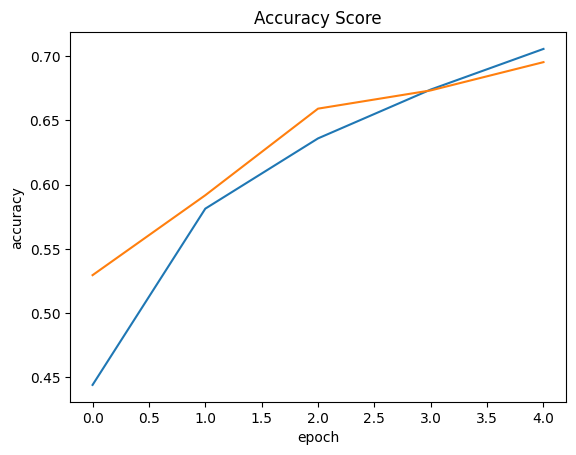

In [13]:
plt.plot(history.history['accuracy'],label='Accuracy')
plt.plot(history.history['val_accuracy'],label='epoch')
plt.title("Accuracy Score")
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.show()

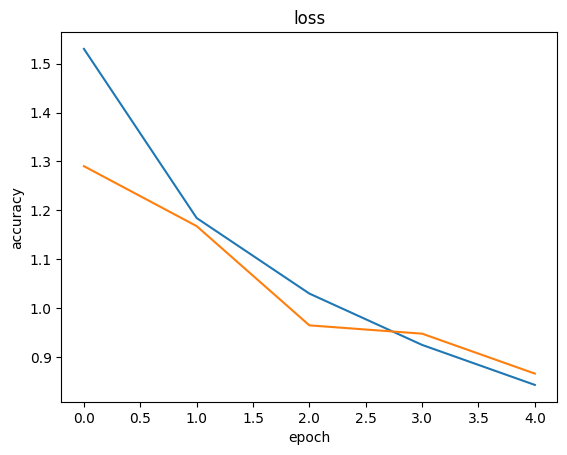

In [14]:
plt.plot(history.history['loss'],label='Accuracy')
plt.plot(history.history['val_loss'],label='epoch')
plt.title("loss")
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.show()